# Tubes 1 IF3270 Pembelajaran Mesin

**Nama Anggota:**
- 13523137 — Muhammad Aulia Azka
- 13523147 — Frederiko Eldad Mugiyono
- 13523149 — Naufarrel Zhafif Abhista

**Kelas:** K3

---

In [3]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 0. Import Libraries & Load Data

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from pathlib import Path

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay


import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [5]:
csv_path = Path("..") / "data" / "global_student_placement_and_salary.csv"
df = pd.read_csv(csv_path)

df.head()

,cgpa,backlogs,college_tier,country,university_ranking_band,internship_count,aptitude_score,communication_score,specialization,industry,internship_quality_score,placement_status
0,7.397371,1,Tier 2,Canada,100-300,2,53.574150,64.177062,Data Science,Consulting,5.481450,Placed
1,6.889389,0,Tier 3,UK,300+,1,60.687750,88.346052,Data Science,Consulting,4.625099,Placed
2,7.518151,0,Tier 1,UK,100-300,2,64.568750,69.493171,Cybersecurity,Healthcare,5.227939,Placed
3,8.218424,0,Tier 2,UK,100-300,3,73.461500,78.204854,AI/ML,Tech,5.150674,Placed
4,6.812677,1,Tier 2,USA,100-300,4,86.518121,44.680881,Data Science,Consulting,3.888824,Placed


In [6]:
target_col = "placement_status"
stratify_col = df[target_col] if df[target_col].nunique() < 50 else None
train_set, val_set = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=stratify_col
)

print(f"train_set: {train_set.shape}")
print(f"val_set: {val_set.shape}")

train_set: (8000, 12)
val_set: (2000, 12)


---
## 1. Exploratory Data Analysis (EDA)


### 1.1 Gambaran Umum Dataset

In [ ]:
train_set.head()

,timestamp,device_id,device_type,cpu_usage,memory_usage,network_in_kb,network_out_kb,packet_rate,avg_response_time_ms,service_access_count,failed_auth_attempts,is_encrypted,geo_location_variation,label
0,2025-06-20 14:36:05.452400,6940e6e9-453f-42fb-a937-9a82cfdc5f07,smart,21.46,13.00,380,440,923,490.39,9,3,1,16.24,Anomaly_DoS
1,2025-06-20 15:11:09.452400,f0936d65-2138-4db7-8be2-c62f3cce3c3f,sensor,33.44,50.97,1149,167,515,420.61,4,7,0,10.63,Normal
2,2025-06-20 14:48:38.452400,890e413e-cfb7-4015-a775-7da0140936ad,smart,81.31,57.71,787,582,660,45.50,3,1,0,2.02,Normal
3,2025-06-20 12:52:15.452400,d4b4a55a-c452-450f-a262-0d450ca2e491,camera,32.31,78.45,1082,627,469,234.26,8,9,1,3.51,Normal
4,2025-06-20 13:22:35.452400,4a8028cb-1b48-4e43-a01c-a11f9c3acddd,camera,54.56,79.05,1476,546,578,426.41,3,6,0,8.94,Normal


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   timestamp               8000 non-null   object 
 1   device_id               8000 non-null   object 
 2   device_type             8000 non-null   object 
 3   cpu_usage               8000 non-null   float64
 4   memory_usage            8000 non-null   float64
 5   network_in_kb           8000 non-null   int64  
 6   network_out_kb          8000 non-null   int64  
 7   packet_rate             8000 non-null   int64  
 8   avg_response_time_ms    8000 non-null   float64
 9   service_access_count    8000 non-null   int64  
 10  failed_auth_attempts    8000 non-null   int64  
 11  is_encrypted            8000 non-null   int64  
 12  geo_location_variation  8000 non-null   float64
 13  label                   8000 non-null   object 
dtypes: float64(4), int64(6), object(4)
memor

In [ ]:
train_df.describe(include='all')

,timestamp,device_id,device_type,cpu_usage,memory_usage,network_in_kb,network_out_kb,packet_rate,avg_response_time_ms,service_access_count,failed_auth_attempts,is_encrypted,geo_location_variation,label
count,8000,8000,8000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000
unique,8000,8000,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
top,2025-06-20 15:11:22.452400,5f2c6cbc-7fa8-41ec-a8ab-f292680de912,sensor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Normal
freq,1,1,2109,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6358
mean,NaN,NaN,NaN,50.193126,47.403276,758.705875,749.064875,500.586000,259.671807,5.058250,5.013500,0.495000,9.994128,NaN
std,NaN,NaN,NaN,23.249586,21.577041,427.389831,430.454243,285.324783,138.612259,2.577584,3.168528,0.500006,5.809651,NaN
min,NaN,NaN,NaN,10.010000,10.030000,10.000000,10.000000,5.000000,20.170000,1.000000,0.000000,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,30.215000,28.782500,390.000000,375.000000,253.000000,141.337500,3.000000,2.000000,0.000000,4.980000,NaN
50%,NaN,NaN,NaN,50.345000,47.180000,758.000000,742.000000,500.000000,257.655000,5.000000,5.000000,0.000000,9.990000,NaN
75%,NaN,NaN,NaN,70.265000,65.887500,1131.000000,1120.000000,746.000000,379.985000,7.000000,8.000000,1.000000,15.040000,NaN


In [ ]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [ ]:
# Distribusi kelas target
print(train_df['label'].value_counts())
print(train_df['label'].value_counts(normalize=True).round(3))

label
Normal               6358
Anomaly_DoS           798
Anomaly_Injection     450
Anomaly_Spoofing      394
Name: count, dtype: int64
label
Normal               0.795
Anomaly_DoS          0.100
Anomaly_Injection    0.056
Anomaly_Spoofing     0.049
Name: proportion, dtype: float64


### 1.2 Visualisasi 1 — [Judul Visualisasi]


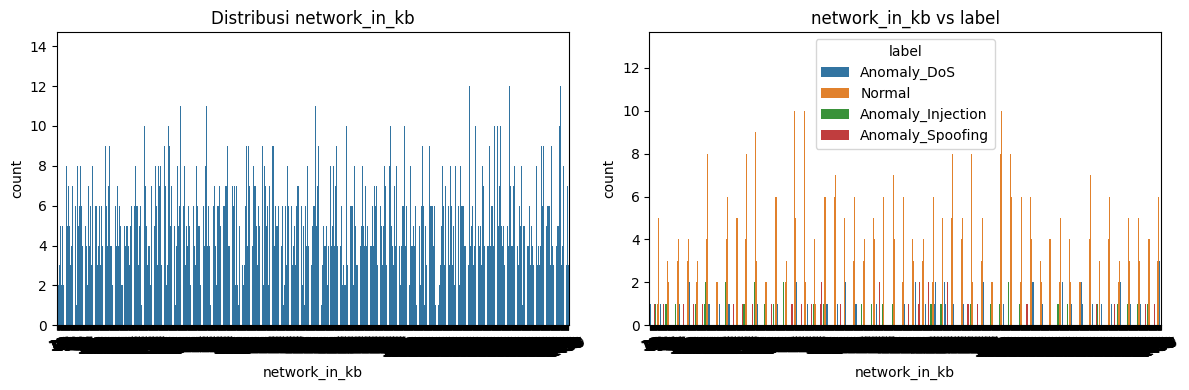

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=train_df, x='network_in_kb', ax=axes[0])
axes[0].set_title('Distribusi network_in_kb')
axes[0].tick_params(axis="x", rotation=20)

sns.countplot(data=train_df, x='network_in_kb', hue='label', ax=axes[1])
axes[1].set_title('network_in_kb vs label')
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title='label')

plt.tight_layout()
plt.show()

### 1.3 Visualisasi 2 — [Judul Visualisasi]


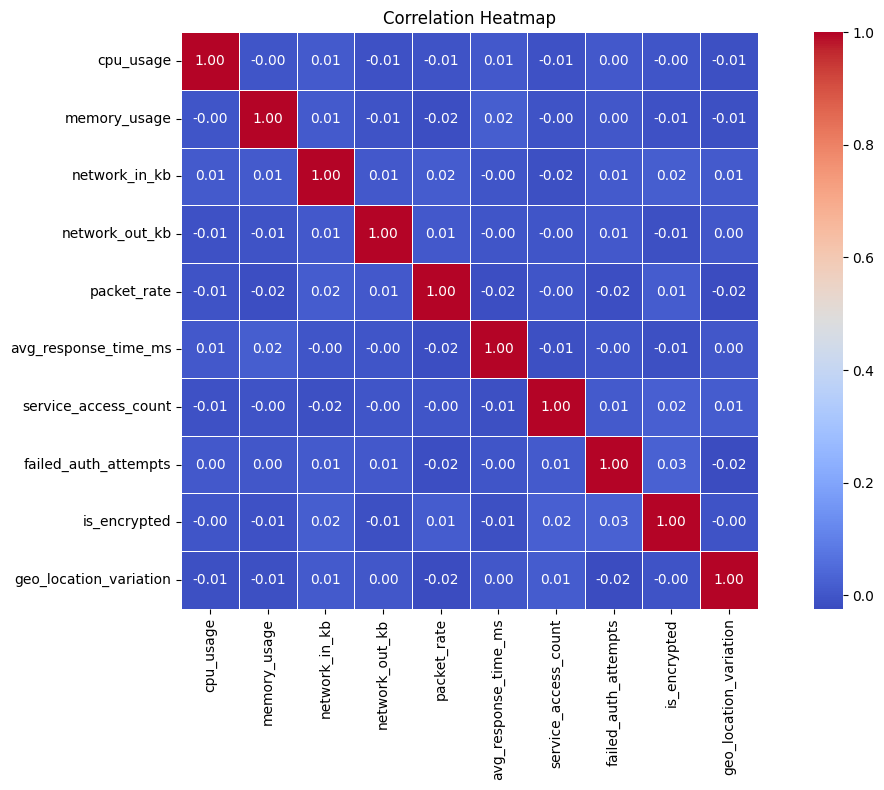

In [ ]:
num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()

plt.figure(figsize=(12, 8))
corr_matrix = train_df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### 1.4 Visualisasi 3 — [Judul Visualisasi]


TypeError: 'method' object is not subscriptable

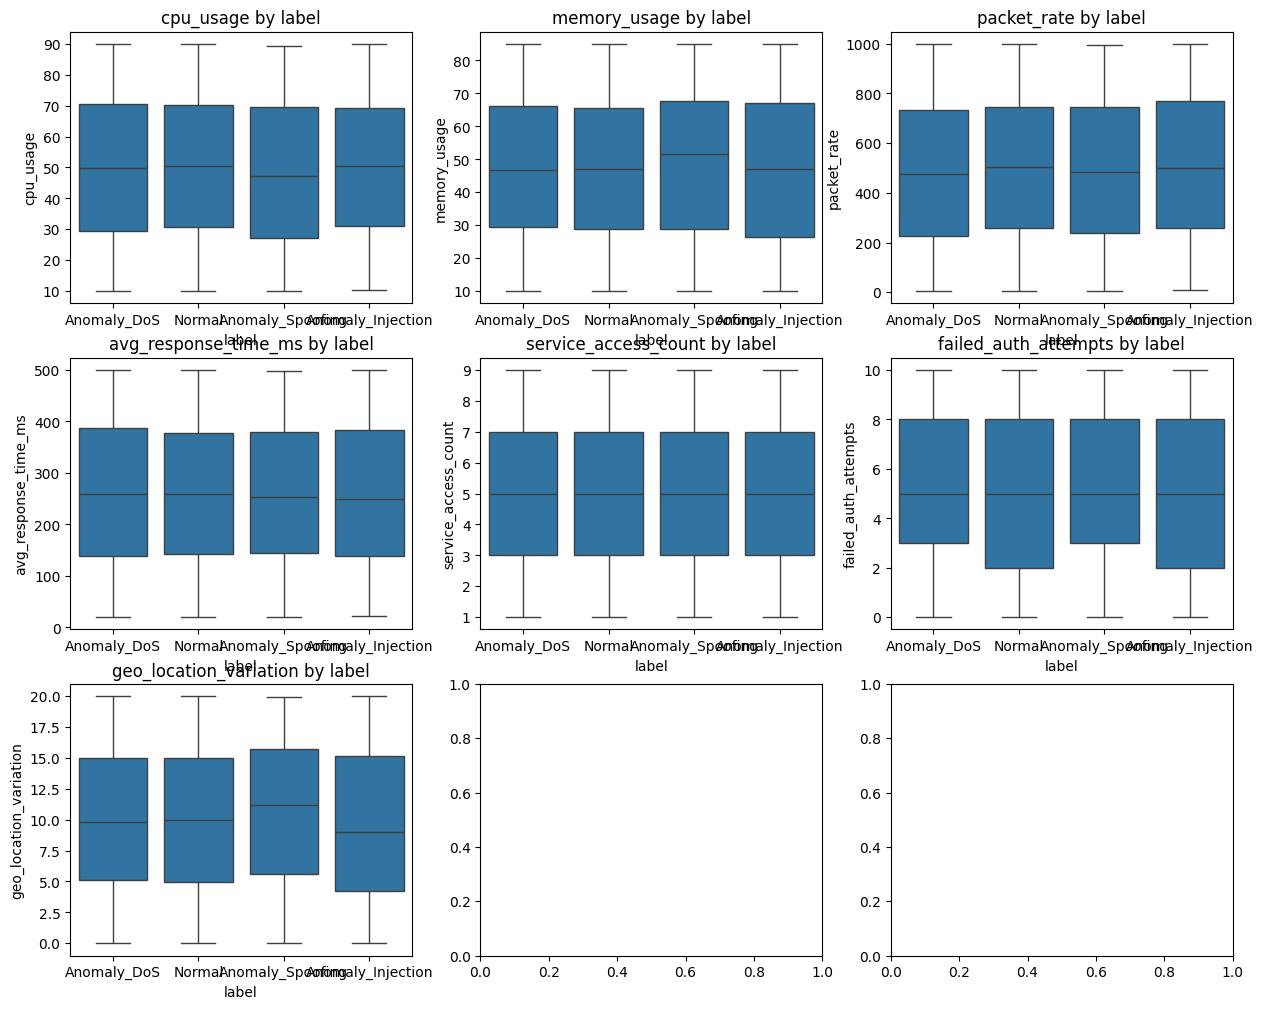

In [ ]:
num_features = ['cpu_usage', 'memory_usage', 'packet_rate',
                'avg_response_time_ms', 'service_access_count', 'failed_auth_attempts', 'geo_location_variation']

n = len(num_features)
cols = 3
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, num_features):
    sns.boxplot(data=train_df, x='label', y=col, ax=ax)
    ax.set_title(f'{col} by label')

for ax in axes[n:]:
  ax.axis["off"]

plt.tight_layout()
plt.show()

---
## 2. Data Cleaning and Preprocessing


In [ ]:
TARGET_COL = 'label'
ID_COL     = 'device_id'
TS_COL = "timestamp"

CAT_COLS = ['device_type', 'is_encrypted']
NUM_COLS = [c for c in train_df.columns if c not in CAT_COLS + [TARGET_COL, ID_COL, TS_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan
train = train_df.copy()
test  = test_df.copy()

Categorical: ['device_type', 'is_encrypted']
Numerical:   ['cpu_usage', 'memory_usage', 'network_in_kb', 'network_out_kb', 'packet_rate', 'avg_response_time_ms', 'service_access_count', 'failed_auth_attempts', 'geo_location_variation']


### 2.1 Feature Engineering

### 2.2 Preprocessing


In [ ]:
class IQRClipper(BaseEstimator, TransformerMixin):
  def __init__(self, factor=1.5):
    self.factor = factor

  def fit(self, X, y=None):
    X = np.asarray(X, dtype=float)
    q1 = np.nanquantile(X, 0.25, axis=0)
    q3 = np.nanquantile(X, 0.75, axis=0)
    IQR = q3 - q1
    self.lower_ = q1 - IQR * self.factor
    self.upper_ = q3 + IQR * self.factor
    return self

  def transform(self, X):
    X = np.asarray(X, dtype=float)
    return np.clip(X, self.lower_, self.upper_)

# OneHotEncoder
try:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except:
  onehoten = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("clipper", IQRClipper()),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", onehoten)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, NUM_COLS),
        ("cat", categorical_transformer, CAT_COLS)
    ],
    remainder="drop"
)


### 2.6 Train-Validation Split

In [ ]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL, TS_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)

X_train: (6400, 11) | y_train: (6400,)
X_val:   (1600, 11) | y_val:   (1600,)


---
## 3. Baseline Config


In [ ]:
# Helper: evaluasi model dan simpan hasil
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

In [ ]:
# Pipeline
def make_pipe(model):
  return Pipeline(steps=[
      ("preprocessor", preprocessor),
      ("model", model)
  ])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune_model(pipe, param_grid=None, param_distributions=None, n_iter=5, scoring="f1_macro"):
  if param_distributions is not None:
    search = RandomizedSearchCV(
        pipe,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        random_state=RANDOM_STATE,
        verbose=1
    )
  else:
    search = GridSearchCV(
        pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=cv,
        n_jobs=-1,
        verbose=1
    )

  search.fit(X_train, y_train)
  return search

trained_models = {}
results = {}

# 4. Eksperimen

## 4.1 Variasi Depth dan Width

### 4.1.1 A

In [ ]:
# TODO: Variasi 1

### 4.1.2 B

In [ ]:
# TODO: Variasi 2

### 4.1.3 C

In [ ]:
# TODO: Variasi 3

## 4.2 Variasi Fungsi Aktivasi 

### 4.2.1 A

In [ ]:
# TODO: Variasi Base Arsitektur 1

### 4.2.2 B

In [ ]:
# TODO: Variasi Base Arsitektur 2

### 4.2.3 C

In [ ]:
# TODO: Variasi Base Arsitektur 3

## 4.3 Variasi Learning Rate

### 4.3.1 A

In [ ]:
# TODO: Variasi Learning Rate 1

### 4.3.2 B

In [ ]:
# TODO: Variasi Learning Rate 2

### 4.3.3 C

In [ ]:
# TODO: Variasi Learning Rate 3

## 4.4 Pengaruh Regularisasi

### 4.4.1 A

In [ ]:
# TODO: Tanpa Regularisasi

### 4.4.2 B

In [ ]:
# TODO: Regularisasi L1

### 4.4.3 C

In [ ]:
# TODO: Regularisasi L2

## 4.5 Uji Perbandingan

### 4.5.1 SKLearn

In [ ]:
# TODO: Implementasi SKlearn

### 4.5.2 Scratch

In [ ]:
# TODO: Implementasi Scratch